In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/ev_cleaned.csv")
df.head()

,vehicle_category,make,model,manufacture_year,district,count
0,THREE WHEELER,BAJAJ,AR4S-UG,2010.0,COLOMBO,1
1,MOTOR CYCLE,SOURCE LINK,CAGW01,2016.0,COLOMBO,1
2,CAR,MERCEDES BENZ,B CLASS,2016.0,COLOMBO,2
3,MOTOR CYCLE,RW,JINBAO,2016.0,COLOMBO,5
4,MOTOR CYCLE,RW,HANBAO,2016.0,PUTTALAM,1


In [2]:
print("Total records:", len(df))
print("Total vehicles (sum of count):", df['count'].sum())
print("Year range:", df['manufacture_year'].min(), "-", df['manufacture_year'].max())
print("Number of districts:", df['district'].nunique())
print("Number of vehicle categories:", df['vehicle_category'].nunique())
print("Number of unique makes:", df['make'].nunique())

Total records: 6536
Total vehicles (sum of count): 65197
Year range: 1965.0 - 2025.0
Number of districts: 25
Number of vehicle categories: 10
Number of unique makes: 314


In [3]:
print(df['manufacture_year'].dtype)

float64


In [4]:
df['manufacture_year'] = df['manufacture_year'].astype('Int64')
print(df['manufacture_year'].dtype)

Int64


In [5]:
category_totals = df.groupby('vehicle_category')['count'].sum().sort_values(ascending=False)
print(category_totals)

vehicle_category
MOTOR CYCLE                  51795
CAR                          12761
THREE WHEELER                  435
DUAL PURPOSE (COMMERCIAL)       96
MOTOR TRICYCLE VAN              48
SPECIAL PURPOSE VEHICLE         29
SINGLE CAB                      25
LAND VEHICLE (SMALL)             5
MOTOR LORRY (COMMERCIAL)         2
THREE WHEELER CAR                1
Name: count, dtype: int64


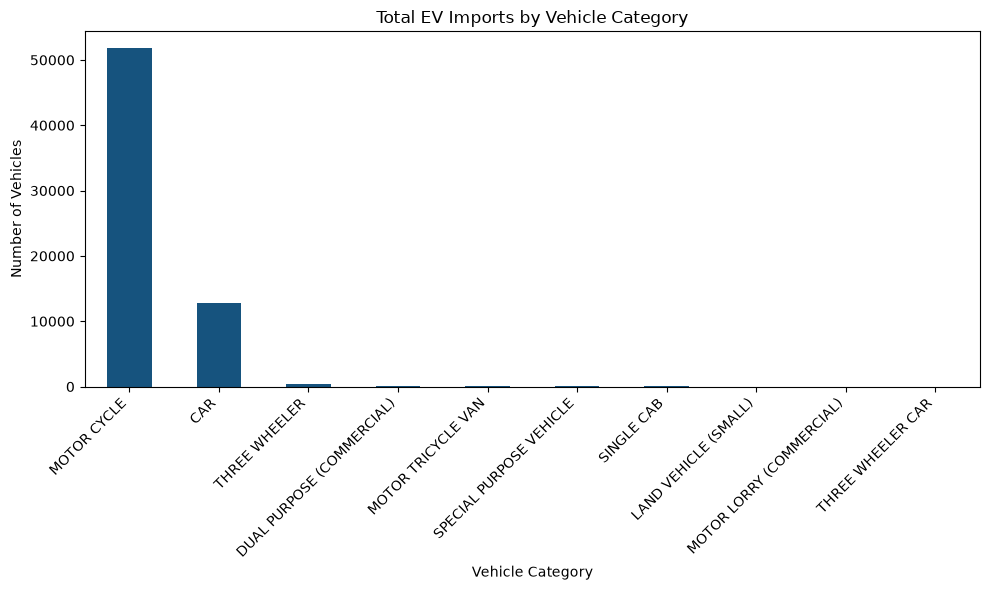

In [6]:
plt.figure(figsize=(10,6))
category_totals.plot(kind='bar', color='#16537e')
plt.title('Total EV Imports by Vehicle Category')
plt.ylabel('Number of Vehicles')
plt.xlabel('Vehicle Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/category_distribution.png', dpi=150)
plt.show()

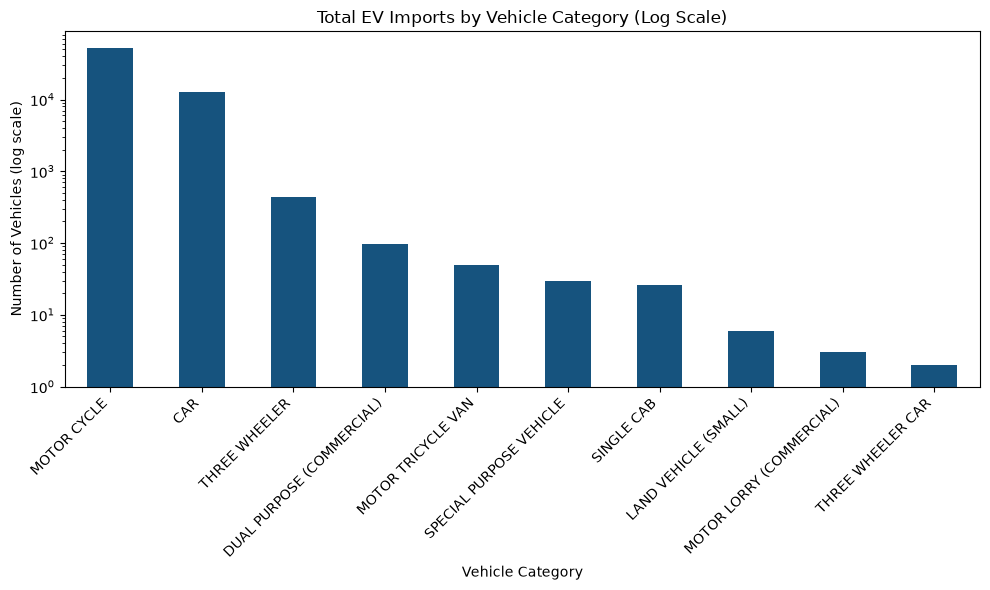

In [7]:
plt.figure(figsize=(10,6))
category_totals.plot(kind='bar', color='#16537e', log=True)
plt.title('Total EV Imports by Vehicle Category (Log Scale)')
plt.ylabel('Number of Vehicles (log scale)')
plt.xlabel('Vehicle Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/category_distribution_log.png', dpi=150)
plt.show()

### Vehicle Category Distribution

EV imports in Sri Lanka are overwhelmingly dominated by **motorcycles**, which account for
approximately **79%** of all registered EV imports (51,795 of 65,197 vehicles), followed by
**cars** at roughly **20%** (12,761 vehicles). All remaining categories combined — three
wheelers, dual purpose commercial vehicles, motor tricycle vans, and others — make up less
than **1%** of total imports.

A standard linear-scale bar chart makes this imbalance visually accurate but analytically
unhelpful, since every category outside motorcycles and cars appears indistinguishable from
zero. A **log-scale bar chart** is used instead, which preserves the true magnitude of
motorcycle dominance while still making it possible to compare the smaller categories to
one another.

**Key takeaway:** Sri Lanka's EV adoption story is, in practice, primarily a story of
electric motorcycle adoption, not electric cars.

### Top Vehicle Makes

Since `make` has 314 unique values, we focus on the top 15 by total vehicles imported
(summed via `count`, since each row represents an aggregated group rather than a
single vehicle). This shows which brands are actually driving Sri Lanka's EV import volume.

In [8]:
top_makes = df.groupby('make')['count'].sum().sort_values(ascending=False).head(15)
print(top_makes)

make
YADEA          29603
NISSAN          4529
BYD             4366
NWOW            2856
AIMA            2206
RISE            2136
LIMA            1517
QUANLE          1491
TVS             1480
SOLID           1268
LUYUAN          1199
TMR QUANLE       939
TOYOTA           902
BAW              865
LUYUAN ALFA      809
Name: count, dtype: int64


In [9]:
# Group by make and sum the 'count' column (not row count, since data is pre-aggregated)
# Take the top 15 makes by total vehicles imported
top_makes = df.groupby('make')['count'].sum().sort_values(ascending=False).head(15)
print(top_makes)

make
YADEA          29603
NISSAN          4529
BYD             4366
NWOW            2856
AIMA            2206
RISE            2136
LIMA            1517
QUANLE          1491
TVS             1480
SOLID           1268
LUYUAN          1199
TMR QUANLE       939
TOYOTA           902
BAW              865
LUYUAN ALFA      809
Name: count, dtype: int64


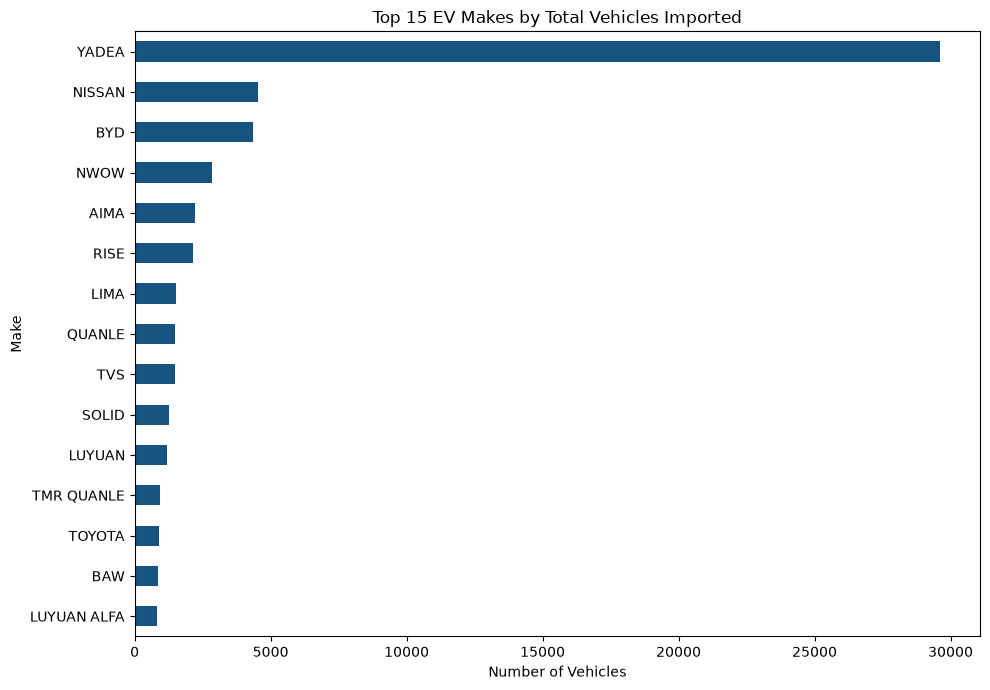

In [12]:
# Horizontal bar chart of top 15 makes by total vehicles imported
plt.figure(figsize=(10,7))
top_makes.sort_values().plot(kind='barh', color='#16537e')
plt.title('Top 15 EV Makes by Total Vehicles Imported')
plt.xlabel('Number of Vehicles')
plt.ylabel('Make')
plt.tight_layout()
plt.savefig('../visuals/top_makes.png', dpi=150)
plt.show()

### Top Vehicle Makes

**YADEA** dominates Sri Lanka's EV import market, accounting for roughly **45%** of all
imported EVs (29,603 of 65,197 vehicles) — more than the next several brands combined.
This aligns with the earlier finding that motorcycles drive the vast majority of EV imports,
since YADEA is primarily an electric motorcycle/scooter manufacturer.

**NISSAN** and **BYD** are the leading electric car brands (4,529 and 4,366 vehicles
respectively), but at roughly 1/7th the volume of YADEA. **TOYOTA** is the only other
traditional automaker to appear in the top 15, with a small fraction of YADEA's volume.

**Key takeaway:** the EV import market in Sri Lanka is not evenly split between competing
car and motorcycle brands — it is heavily concentrated around a single dominant motorcycle
brand, with car brands playing a comparatively minor role in overall volume.